# Chapter 6. 고전 데이터의 양자 인코딩

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 1**

## 학습 목표
- Basis / Angle / Amplitude 인코딩의 동작과 회로 구조 비교
- 각 인코딩의 큐비트 효율과 회로 깊이 트레이드오프 이해
- Data re-uploading이 모델의 표현력을 어떻게 확장하는지 실험으로 확인

In [9]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 6.1 Basis encoding
이진 데이터를 computational basis state에 그대로 매핑한다.
예: x = [1, 0, 1] → |101⟩

In [2]:
dev = qml.device('default.qubit', wires=3)

@qml.qnode(dev)
def basis_encoding(x):
    qml.BasisEmbedding(x, wires=range(3))
    return qml.state()

x_bits = [1, 0, 1]
state = basis_encoding(x_bits)
# |101> = index 5 (binary 101)
print(f'입력 비트: {x_bits}')
print(f'상태 인덱스 (1인 위치): {np.argmax(np.abs(state))}')
print(f'전체 상태: {np.round(state.real, 2)}')

입력 비트: [1, 0, 1]
상태 인덱스 (1인 위치): 5
전체 상태: [0. 0. 0. 0. 0. 1. 0. 0.]


**특징.** Basis encoding은 N비트를 N큐비트에 그대로 담는다 — 큐비트 효율이 좋지 않지만(고전 표현과 같은 차원) 회로가 매우 단순하다.

## 6.2 Angle encoding
실수 특징값 `x_i`를 회전 각도로 사용한다. N차원 데이터 → N큐비트.

입력 특징: [0.5 1.2 0.8]
상태 진폭 (실수부): [0.737 0.311 0.504 0.213 0.188 0.08  0.129 0.054]


Matplotlib is building the font cache; this may take a moment.


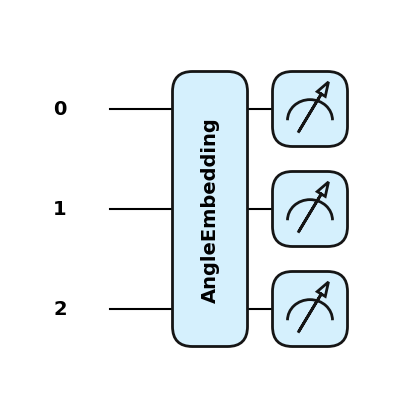

In [5]:
@qml.qnode(dev)
def angle_encoding(x):
    qml.AngleEmbedding(x, wires=range(3), rotation='Y')
    return qml.state()

x_real = np.array([0.5, 1.2, 0.8])
state = angle_encoding(x_real)
print(f'입력 특징: {x_real}')
print(f'상태 진폭 (실수부): {np.round(state.real, 3)}')
fig, ax = qml.draw_mpl(angle_encoding, style='pennylane')(x_real)
plt.show()

## 6.3 Amplitude encoding
길이 2^n 벡터를 정규화해 양자 상태의 진폭으로 사용한다. **N큐비트로 2^N차원 데이터를 표현** — 정보 밀도가 가장 높다.

In [6]:
dev2 = qml.device('default.qubit', wires=2)

@qml.qnode(dev2)
def amplitude_encoding(x):
    qml.AmplitudeEmbedding(x, wires=range(2), normalize=True)
    return qml.state()

# 4차원 벡터를 2큐비트에 인코딩
x_vec = np.array([1.0, 2.0, 3.0, 4.0])
state = amplitude_encoding(x_vec)
print(f'입력 벡터: {x_vec}')
print(f'정규화된 벡터: {x_vec / np.linalg.norm(x_vec)}')
print(f'인코딩된 상태:  {np.round(state.real, 3)}')

입력 벡터: [1. 2. 3. 4.]
정규화된 벡터: [0.18257419 0.36514837 0.54772256 0.73029674]
인코딩된 상태:  [0.183 0.365 0.548 0.73 ]


두 결과가 정확히 일치한다. amplitude encoding은 큐비트 효율이 최고지만, 임의의 상태를 준비하는 회로는 큐비트 수에 지수적으로 깊어질 수 있다.

## 6.4 세 인코딩 비교 정리
| 인코딩 | 큐비트 수 | 회로 깊이 | 정보 밀도 |
|--------|-----------|-----------|-----------|
| Basis | N (비트 수) | O(N) | 낮음 |
| Angle | N (특징 수) | O(N) | 중간 |
| Amplitude | log₂(N) | O(N) 이상 | 높음 |

## 6.5 Data re-uploading: 인코딩을 반복하기
단일 큐비트로 비선형 함수를 학습할 때 인코딩을 한 번만 하면 표현력에 한계가 있다. Re-uploading은 변분 게이트 사이에 인코딩을 반복해 표현력을 확장한다.

두 가지 회로 (단일 인코딩 vs 다중 re-uploading)를 비교해본다.

In [7]:
dev1 = qml.device('default.qubit', wires=1)

@qml.qnode(dev1, interface='autograd')
def single_upload(x, params):
    # 인코딩 1번 + 변분 회전
    qml.RY(x, wires=0)
    qml.RZ(params[0], wires=0)
    qml.RY(params[1], wires=0)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev1, interface='autograd')
def reuploading(x, params):
    # 인코딩 + 변분 회전을 L번 반복
    n_layers = len(params) // 2
    for layer in range(n_layers):
        qml.RY(x, wires=0)
        qml.RZ(params[2 * layer], wires=0)
        qml.RY(params[2 * layer + 1], wires=0)
    return qml.expval(qml.PauliZ(0))

# 목표 함수: 비선형 함수
def target(x):
    return np.cos(3 * x) * np.exp(-x ** 2 / 4)

x_train = np.linspace(-np.pi, np.pi, 30)
y_train = target(x_train)

def make_cost(model, params_shape):
    def cost(p):
        preds = pnp.stack([model(x, p) for x in x_train])
        return pnp.mean((preds - y_train) ** 2)
    return cost

# 두 모델 학습
def train(model, n_params, steps=80):
    params = pnp.array(
        np.random.RandomState(0).uniform(-1, 1, n_params),
        requires_grad=True,
    )
    opt = qml.AdamOptimizer(0.1)
    cost_fn = make_cost(model, n_params)
    for _ in range(steps):
        params = opt.step(cost_fn, params)
    return params, cost_fn(params)

p_single, c_single = train(single_upload, 2)
p_reup, c_reup = train(reuploading, 10)  # 5 layers
print(f'단일 인코딩 MSE:    {c_single:.4f}')
print(f'5층 re-uploading MSE: {c_reup:.4f}')

단일 인코딩 MSE:    0.1927
5층 re-uploading MSE: 0.0022


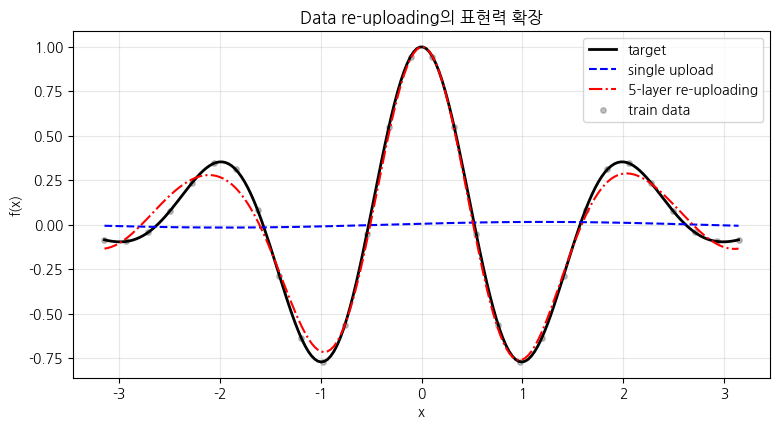

In [10]:
# 학습된 모델로 함수 근사 결과 시각화
x_plot = np.linspace(-np.pi, np.pi, 200)
y_single = np.array([single_upload(x, p_single) for x in x_plot])
y_reup = np.array([reuploading(x, p_reup) for x in x_plot])

plt.figure(figsize=(9, 4.5))
plt.plot(x_plot, target(x_plot), 'k-', label='target', lw=2)
plt.plot(x_plot, y_single, 'b--', label='single upload')
plt.plot(x_plot, y_reup, 'r-.', label='5-layer re-uploading')
plt.scatter(x_train, y_train, color='gray', s=15, alpha=0.5, label='train data')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Data re-uploading의 표현력 확장')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**관찰.** 단일 인코딩은 단순한 정현파 형태밖에 표현하지 못하지만, re-uploading은 더 복잡한 비선형 함수를 학습할 수 있다. 다음 장에서 이 현상을 "양자 모델 = 푸리에 급수" 관점에서 정량적으로 설명한다.

## 6.6 정리
- 인코딩은 양자 모델의 표현력을 결정하는 가장 중요한 설계 결정이다.
- Angle encoding은 입문에 표준, Amplitude encoding은 정보 밀도가 가장 높다.
- Data re-uploading으로 동일한 큐비트에서도 더 풍부한 함수를 표현할 수 있다.